In [1]:
import numpy as np
import matplotlib.pyplot as plt
from safety_formation.control_law.cbf import CentralizedCBF

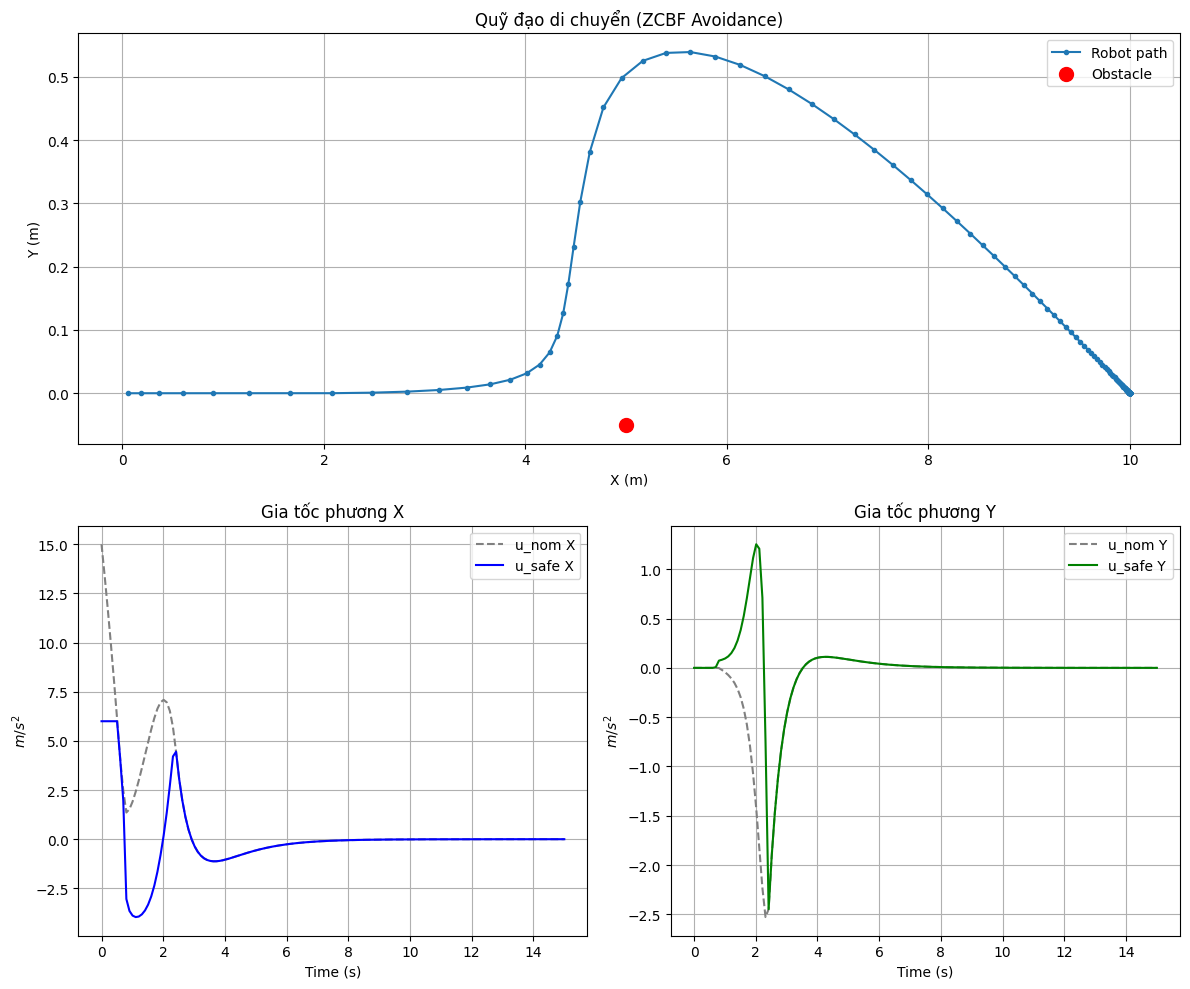

In [2]:
# Khởi tạo thông số
dt = 0.1
T = 15.0 # Tăng thời gian để xem robot vượt qua vật cản
steps = int(T / dt)
gamma =1 # Tăng gamma một chút để phản ứng mượt hơn
d_min = 0.5 

x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
x_obs = np.array([5.0, -0.05, 0, 0.0]) 
x_target = np.array([10.0, 0.0, 0.0, 0.0])

alpha_agent = 6.0
alpha_obs = 0.0 

history = []
u_hat_history = []
u_safe_history = []

cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

for k in range(steps):
    # 1. Tính u_nom
    # Dùng x_agent[0:2] (vị trí hiện tại) thay vì x_init để robot luôn hướng về đích
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]
    
    # 2. Mock Data
    class MockAgent:
        def __init__(self, state, alpha, id):
            self.state = state.reshape(4,1); self.alpha = alpha
            self.id = id; self.pos = state[0:2]; self.vel = state[2:4]
            self.gamma = gamma
    
    a1 = MockAgent(x_agent, alpha_agent, 1)
    a2 = MockAgent(x_obs, alpha_obs, 2)
    
    class MockTopo:
        adj_matrix = np.array([[0, 1], [1, 0]])
    
    # 3. Lọc qua CBF
    u_nom_all = np.array([u_hat, [0, 0]]) 
    u_safe_all = cbf_filter.compute_safe_control([a1, a2], MockTopo(), u_nom_all)
    
    if u_safe_all is not None:
        u_apply = u_safe_all[0]
    else:
        u_apply = np.array([0, 0])

    # Lưu lịch sử điều khiển
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # 4. Update Physics
    x_agent[2:4] += u_apply * dt
    x_agent[0:2] += x_agent[2:4] * dt
    history.append(x_agent.copy())

# --- Chuyển dữ liệu sang mảng Numpy ---
history = np.array(history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
time = np.linspace(0, T, steps)

# --- VẼ ĐỒ THỊ ---
fig = plt.figure(figsize=(12, 10))

# 1. Quỹ đạo di chuyển
ax1 = plt.subplot(2, 1, 1)
ax1.plot(history[:, 0], history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter([5.0], [-0.05], color='red', s=100, label='Obstacle', zorder=5)
ax1.set_title("Quỹ đạo di chuyển (ZCBF Avoidance)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.legend(); ax1.grid(True)

# 2. Tín hiệu điều khiển u_x
ax2 = plt.subplot(2, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom X')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe X')
ax2.set_title("Gia tốc phương X")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("$m/s^2$")
ax2.legend(); ax2.grid(True)

# 3. Tín hiệu điều khiển u_y
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom Y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe Y')
ax3.set_title("Gia tốc phương Y")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("$m/s^2$")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

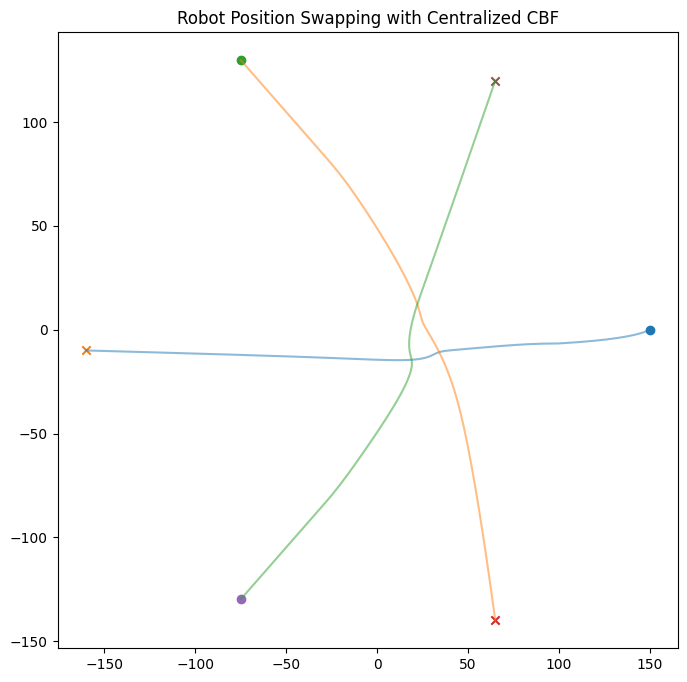

In [3]:
# --- Cấu hình mô phỏng ---
N = 3           # 20 robot như trong bài báo
R_circle = 150   # Bán kính vòng tròn
dt = 0.1
T_max = 100
gamma = 0.1
d_min = 9.0      # Ds = 10
k1, k2 = 1.0, 2.0 # Hệ số PD controller

# --- Khởi tạo trạng thái ---
agents_list = []
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = pos
        self.vel = np.zeros(2)
        self.target = target
        self.alpha = 20.0 # Gia tốc tối đa
        self.gamma = gamma

for i in range(N):
    angle = 2 * np.pi * i / N
    # Vị trí ban đầu trên vòng tròn
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)])
    # Đích đến ở phía đối diện
    target = -pos -10
    agents_list.append(AgentObj(i, pos, target))

# Giả lập Topology (Tất cả thấy nhau - Fully Connected cho Centralized)
class FullTopology:
    adj_matrix = np.ones((N, N)) - np.eye(N)

cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- Vòng lặp mô phỏng ---
history = [[] for _ in range(N)]

for t in range(int(T_max/dt)):
    # 1. Tính u_nom cho toàn bộ N robot (PD Control)
    u_nom_all = []
    for ag in agents_list:
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # 2. Lọc qua Centralized CBF
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    
    if u_safe_all is None: break

    # 3. Cập nhật vật lý
    for i, ag in enumerate(agents_list):
        ag.vel += u_safe_all[i] * dt
        ag.pos += ag.vel * dt
        history[i].append(ag.pos.copy())

# --- Vẽ quỹ đạo (Sử dụng Matplotlib để xem kết quả giống Fig 3) ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
for i in range(N):
    traj = np.array(history[i])
    plt.plot(traj[:,0], traj[:,1], alpha=0.5)
    plt.scatter(traj[0,0], traj[0,1], marker='o') # Start
    plt.scatter(traj[-1,0], traj[-1,1], marker='x') # End
plt.title("Robot Position Swapping with Centralized CBF")
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

# --- Cấu hình mô phỏng ---
N = 3           # 20 robot như trong bài báo
R_circle = 150   # Bán kính vòng tròn
dt = 0.1
T_max = 16
gamma = 10
d_min = 15.0      # Ds = 10
k1, k2 = 1.0, 2.0 # Hệ số PD controller

# 2. Định nghĩa Class (Đảm bảo dùng float)
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = np.array(pos, dtype=float)
        self.vel = np.zeros(2, dtype=float)
        self.target = np.array(target, dtype=float)
        self.alpha = 20.0 # Gia tốc tối đa

# 3. KHỞI TẠO LẠI TRẠNG THÁI (Bước quan trọng nhất)
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N
    # Vị trí bắt đầu trên vòng tròn
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)], dtype=float)
    # Đích đến đối diện (Swap vị trí)
    target = -pos - 10
    agents_list.append(AgentObj(i, pos, target))

# 4. Thiết lập Figure cho Animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Robot Swapping - CBF Simulation")

# Vẽ các đích đến (X đỏ)
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

# Khởi tạo các đối tượng đồ họa
points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# 5. Hàm cập nhật (Update) cho từng Frame
def update(frame):
    global agents_list, history
    
    # Tính toán điều khiển nominal (u_nom)
    u_nom_all = []
    for ag in agents_list:
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # Tính toán CBF (Sử dụng bộ lọc của bạn)
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    # u_safe_all = u_nom_all # Tạm thời dùng u_nom để test di chuyển

    # Cập nhật vật lý (Tích phân Euler)
    for i in range(N):
        agents_list[i].vel += u_safe_all[i] * dt
        agents_list[i].pos += agents_list[i].vel * dt
        
        # Cập nhật dữ liệu vẽ
        history[i].append(agents_list[i].pos.copy())
        traj = np.array(history[i])
        
        points[i].set_data([agents_list[i].pos[0]], [agents_list[i].pos[1]])
        trails[i].set_data(traj[:, 0], traj[:, 1])

    # Log debug mỗi 50 frame
    if frame % 50 == 0:
        print(f"Frame {frame}: Agent 0 đang ở {agents_list[0].pos}")

    info_text.set_text(f"Time: {frame*dt:.1f}s")
    return points + trails + [info_text]

# 6. Tiến hành Render và Lưu file
print("Bắt đầu quá trình lưu video MP4...")
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

# Cấu hình Writer (Yêu cầu ffmpeg đã cài đặt)
try:
    writer = FFMpegWriter(fps=int(1/dt), bitrate=2000)
    ani.save("centralized_cbf_validation.mp4", writer=writer)
    print("Xong! File 'robot_cbf_simulation.mp4' đã được tạo.")
except Exception as e:
    print(f"Lỗi khi lưu video: {e}")

plt.close(fig)

Bắt đầu quá trình lưu video MP4...
Frame 0: Agent 0 đang ở [ 1.498e+02 -1.000e-01]
Frame 0: Agent 0 đang ở [149.4    -0.279]
Frame 0: Agent 0 đang ở [148.8      -0.51941]
Frame 0: Agent 0 đang ở [148.         -0.8065439]
Frame 50: Agent 0 đang ở [  9.58577759 -14.67641676]
Frame 100: Agent 0 đang ở [-151.56814954  -10.20676937]
Frame 150: Agent 0 đang ở [-159.80649674  -10.00473938]
Xong! File 'robot_cbf_simulation.mp4' đã được tạo.
